# Pursuer RL training

End-to-end notebook: env → PPO → evaluation → ONNX export.

Runs in Google Colab (GPU recommended) or local Jupyter. Paired files live at
https://github.com/unclestep/Rogue/tree/develop/rl. Trained model goes to
`rl/models/pursuer.onnx`; Go loads it via `ROGUE_PURSUER_MODEL_PATH`.

**Do not edit the observation layout without updating
`internal/domain/service/rl_observation.go` in lockstep.** The parity cell at
the bottom catches divergence, but only after the fact.


## 1. Setup

In [41]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print('Colab:' , IN_COLAB)


Colab: False


In [42]:
if IN_COLAB:
    %pip install --quiet 'gymnasium>=1.0' 'stable-baselines3>=2.4' torch onnx onnxscript onnxruntime tensorboard matplotlib


## 2. Hyperparameters

In [43]:
from pathlib import Path

CONFIG = {
    'topologies_dir': 'fixtures/topologies',  # swap for 'topologies' after make dump-topologies
    'total_timesteps': 5_000_000,
    'n_envs': 10,
    'max_episode_steps': 200,
    'seed': 42,
    'model_out': 'models/pursuer.onnx',
    'checkpoint_dir': 'checkpoints',
    'tensorboard_log': 'runs',
    # --- Architecture (PursuerCNN + MLP head) ---
    'net_arch': [256, 256, 128],
    'features_dim': 128,          # output width of PursuerCNN (see rl/features.py)
    # --- Curriculum stage 0 — static target ---
    # CurriculumCallback graduates from `training_dummy` → realistic settings
    # once `ep_len_mean < curriculum_len_threshold` and
    # `ep_rew_mean > curriculum_rew_threshold` hold for a rollout window.
    'curriculum_enabled': True,
    'curriculum_start_profile': 'training_dummy',
    'curriculum_len_threshold': 80,
    'curriculum_rew_threshold': 20.0,
    'curriculum_check_freq': 5_000,   # env-step cadence
    # --- Domain randomization (applied by curriculum stage 2) ---
    'max_episode_steps_range': (120, 300),
    'distractor_prob': 0.3,
    'randomize_player_profile': True,
    # --- Early stopping ---
    'use_early_stopping': True,
    'eval_freq': 25_000,
    'eval_episodes': 10,
    'es_patience': 6,
    'es_min_delta': 1.0,
    # --- Telemetry ---
    'ppo_verbose': 0,
    'metrics_log_freq': 2_048,
}
Path(CONFIG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)
CONFIG


{'topologies_dir': 'fixtures/topologies',
 'total_timesteps': 5000000,
 'n_envs': 10,
 'max_episode_steps': 200,
 'seed': 42,
 'model_out': 'models/pursuer.onnx',
 'checkpoint_dir': 'checkpoints',
 'tensorboard_log': 'runs',
 'net_arch': [256, 256, 128],
 'max_episode_steps_range': (120, 300),
 'distractor_prob': 0.3,
 'randomize_player_profile': True,
 'use_early_stopping': True,
 'eval_freq': 25000,
 'eval_episodes': 10,
 'es_patience': 6,
 'es_min_delta': 1.0,
 'ppo_verbose': 0,
 'metrics_log_freq': 2048}

## 3. Environment modules

Sync the env/player modules into the notebook's working dir. In Colab this
pulls fresh copies from the repo; locally you can symlink or rely on the
current working directory being `rl/`.

In [44]:
import os, pathlib, shutil

if IN_COLAB:
    !git clone --depth=1 --filter=blob:none --sparse https://github.com/unclestep/Rogue.git _repo
    !cd _repo && git sparse-checkout set rl cmd/dump-topology
    for name in ('pursuer_env.py', 'scripted_player.py', 'features.py', '__init__.py'):
        src = pathlib.Path('_repo/rl') / name
        if src.exists():
            shutil.copy(src, name)
    shutil.copytree('_repo/rl/fixtures', 'fixtures', dirs_exist_ok=True)
else:
    pass

print('env files in cwd:', sorted(f for f in os.listdir('.') if f.endswith('.py')))


env files in cwd: ['__init__.py', 'pursuer_env.py', 'scripted_player.py']


In [45]:
# Import as local modules — both Colab-copied and local paths work.
import importlib, sys
sys.path.insert(0, '.')
import pursuer_env, scripted_player, features
importlib.reload(pursuer_env)
importlib.reload(scripted_player)
importlib.reload(features)
from pursuer_env import PursuerEnv, OBSERVATION_SIZE, ACTION_COUNT
from scripted_player import scripted_player_policy
from features import PursuerCNN
print('observation_size =', OBSERVATION_SIZE, 'actions =', ACTION_COUNT)


observation_size = 859 actions = 5


## 4. Sanity check: single env

In [46]:
env = PursuerEnv(CONFIG['topologies_dir'], scripted_player_policy, max_episode_steps=50, seed=0)
obs, info = env.reset(seed=0)
print('obs', obs.shape, obs.dtype, 'range', obs.min(), obs.max())
print('loaded', info)
total = 0.0
for _ in range(30):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r
    if term or trunc: break
print('30-step random rollout reward =', round(total, 3))


obs (859,) float32 range 0.0 1.0
loaded {'topology': '0012.json', 'player_profile': 'default', 'has_distractor': False, 'max_steps': 50}
30-step random rollout reward = -0.09


## 5. PPO training

In [47]:
import time
from typing import Any

import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import (
    BaseCallback,
    CallbackList,
    CheckpointCallback,
    EvalCallback,
    StopTrainingOnNoModelImprovement,
)
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor


def make_env(rank: int, stage0: bool = True):
    def _thunk():
        return PursuerEnv(
            CONFIG['topologies_dir'],
            scripted_player_policy,
            max_episode_steps=CONFIG['max_episode_steps'],
            # --- Stage-0 curriculum defaults. Upgraded by CurriculumCallback ---
            max_episode_steps_range=None if stage0 else CONFIG.get('max_episode_steps_range'),
            distractor_prob=0.0 if stage0 else CONFIG.get('distractor_prob', 0.0),
            randomize_player_profile=False if stage0 else CONFIG.get('randomize_player_profile', False),
            fixed_profile=CONFIG['curriculum_start_profile'] if stage0 else 'default',
            seed=CONFIG['seed'] + rank,
        )
    return _thunk


class MetricsHistoryCallback(BaseCallback):
    """Append SB3 logger stats to in-memory lists every `log_freq` steps.
    Replaces `verbose=1` (which bloats the notebook with per-rollout tables)."""

    def __init__(self, log_freq: int, verbose: int = 0):
        super().__init__(verbose)
        self.log_freq = log_freq
        self.history: dict[str, list[Any]] = {
            'timesteps': [], 'ep_rew_mean': [], 'ep_len_mean': [],
            'loss': [], 'policy_loss': [], 'value_loss': [], 'entropy_loss': [],
            'fps': [],
        }
        self._t0 = time.time()
        self._last_log = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_log < self.log_freq:
            return True
        self._last_log = self.num_timesteps
        buf = self.model.ep_info_buffer
        if buf is None or len(buf) == 0:
            return True
        rewards = [ep['r'] for ep in buf]
        lengths = [ep['l'] for ep in buf]
        self.history['timesteps'].append(self.num_timesteps)
        self.history['ep_rew_mean'].append(float(np.mean(rewards)))
        self.history['ep_len_mean'].append(float(np.mean(lengths)))
        logger_vals = self.model.logger.name_to_value
        for k, dst in (('train/loss', 'loss'),
                       ('train/policy_gradient_loss', 'policy_loss'),
                       ('train/value_loss', 'value_loss'),
                       ('train/entropy_loss', 'entropy_loss')):
            self.history[dst].append(float(logger_vals.get(k, np.nan)))
        dt = max(time.time() - self._t0, 1e-6)
        self.history['fps'].append(self.num_timesteps / dt)
        return True


class CurriculumCallback(BaseCallback):
    """Graduates the training envs through difficulty stages.

    Stage 0  — static `training_dummy` target, no distractors, no profile
                randomization. PPO needs this to discover approach→hit loop.
    Stage 1  — realistic fleeing `default` profile, still no distractors.
    Stage 2  — full domain randomization: random profile + distractors.

    Promotion uses the same signal EvalCallback does: SB3 maintains a rolling
    100-episode `ep_info_buffer`. Once `mean(ep_len) < len_thresh` AND
    `mean(ep_rew) > rew_thresh` hold, we call `env_method('set_difficulty', ...)`
    on every worker. Each stage transition resets the monitor window so we
    don't re-promote on stale stats.
    """

    def __init__(
        self,
        check_freq: int,
        len_thresh: int,
        rew_thresh: float,
        verbose: int = 1,
    ):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.len_thresh = len_thresh
        self.rew_thresh = rew_thresh
        self.stage = 0
        self._last_check = 0
        self.history: list[dict[str, Any]] = []

    def _maybe_promote(self) -> bool:
        buf = self.model.ep_info_buffer
        if buf is None or len(buf) < 30:
            return False
        rews = [ep['r'] for ep in buf]
        lens = [ep['l'] for ep in buf]
        mean_rew = float(np.mean(rews))
        mean_len = float(np.mean(lens))
        self.history.append({
            'timesteps': self.num_timesteps, 'stage': self.stage,
            'ep_rew_mean': mean_rew, 'ep_len_mean': mean_len,
        })
        if mean_len < self.len_thresh and mean_rew > self.rew_thresh:
            self.stage += 1
            if self.stage == 1:
                result = self.training_env.env_method(
                    'set_difficulty',
                    fixed_profile='default',
                    distractor_prob=0.0,
                    randomize_player_profile=False,
                )
                if self.verbose:
                    print(f'[curriculum] step={self.num_timesteps} promote -> stage 1 (default profile)  '
                          f'ep_rew={mean_rew:.2f} ep_len={mean_len:.1f}  sample={result[0]}')
            elif self.stage == 2:
                result = self.training_env.env_method(
                    'set_difficulty',
                    fixed_profile='default',
                    distractor_prob=CONFIG.get('distractor_prob', 0.0),
                    randomize_player_profile=CONFIG.get('randomize_player_profile', False),
                )
                if self.verbose:
                    print(f'[curriculum] step={self.num_timesteps} promote -> stage 2 (randomized)  '
                          f'ep_rew={mean_rew:.2f} ep_len={mean_len:.1f}  sample={result[0]}')
            else:
                return False
            # Reset the ep_info buffer so next stage is judged on fresh episodes.
            self.model.ep_info_buffer.clear()
            return True
        return False

    def _on_step(self) -> bool:
        if self.stage >= 2:
            return True
        if self.num_timesteps - self._last_check < self.check_freq:
            return True
        self._last_check = self.num_timesteps
        self._maybe_promote()
        return True


# --- Build envs: stage-0 by default, upgraded by CurriculumCallback ---
vec = SubprocVecEnv([make_env(i, stage0=CONFIG.get('curriculum_enabled', True))
                     for i in range(CONFIG['n_envs'])])
vec = VecMonitor(vec)

# Eval env stays at stage-0 (easiest) until the training agent reaches it;
# for stronger evaluation, we'd spin up a separate random-profile eval env.
eval_vec = DummyVecEnv([make_env(1_000, stage0=CONFIG.get('curriculum_enabled', True))])
eval_vec = VecMonitor(eval_vec)

model = PPO(
    'MlpPolicy',
    vec,
    device='cpu',
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=512,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,  # was 0.01 — boosted to force exploration out of 'never engage' local optimum
    policy_kwargs=dict(
        features_extractor_class=PursuerCNN,
        features_extractor_kwargs=dict(features_dim=CONFIG['features_dim']),
        net_arch=CONFIG['net_arch'],
    ),
    tensorboard_log=CONFIG['tensorboard_log'],
    seed=CONFIG['seed'],
    verbose=CONFIG['ppo_verbose'],
)

ckpt_cb = CheckpointCallback(
    save_freq=max(10_000 // CONFIG['n_envs'], 1),
    save_path=CONFIG['checkpoint_dir'],
    name_prefix='pursuer',
)
metrics_cb = MetricsHistoryCallback(
    log_freq=CONFIG['metrics_log_freq'], verbose=0,
)
callbacks: list[BaseCallback] = [ckpt_cb, metrics_cb]

if CONFIG.get('curriculum_enabled', True):
    curriculum_cb = CurriculumCallback(
        check_freq=CONFIG['curriculum_check_freq'],
        len_thresh=CONFIG['curriculum_len_threshold'],
        rew_thresh=CONFIG['curriculum_rew_threshold'],
        verbose=1,
    )
    callbacks.append(curriculum_cb)

if CONFIG.get('use_early_stopping', False):
    stop_cb = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=CONFIG['es_patience'],
        min_evals=CONFIG['es_patience'],
        verbose=1,
    )
    eval_cb = EvalCallback(
        eval_vec,
        best_model_save_path=CONFIG['checkpoint_dir'],
        log_path=CONFIG['checkpoint_dir'],
        eval_freq=max(CONFIG['eval_freq'] // CONFIG['n_envs'], 1),
        n_eval_episodes=CONFIG['eval_episodes'],
        deterministic=True,
        render=False,
        callback_after_eval=stop_cb,
        verbose=1,
    )
    callbacks.append(eval_cb)

t_start = time.time()
model.learn(total_timesteps=CONFIG['total_timesteps'], callback=CallbackList(callbacks))
elapsed = time.time() - t_start
print(f'trained {model.num_timesteps:,} steps in {elapsed/60:.1f} min '
      f'({model.num_timesteps / elapsed:.0f} steps/s)')


## 5b. Learning curves

Plots from `MetricsHistoryCallback`. If `use_early_stopping` kicked in, the
curves stop before `total_timesteps`. Eval reward is read from
`checkpoints/evaluations.npz` written by `EvalCallback`.

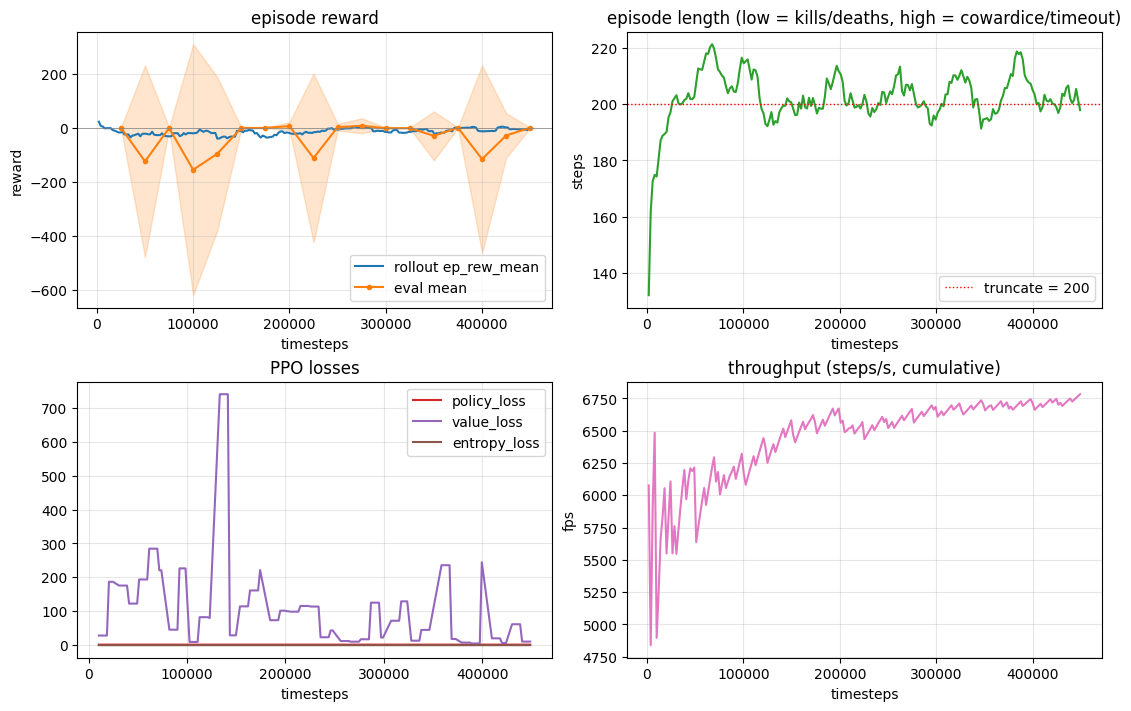

logged 219 rollout points, trained to 450,000 steps


In [39]:
import os
import matplotlib.pyplot as plt
import numpy as np

# --- Rollout history from MetricsHistoryCallback ------------------------
h = metrics_cb.history
ts = np.asarray(h['timesteps'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

ax = axes[0, 0]
if len(ts):
    ax.plot(ts, h['ep_rew_mean'], label='rollout ep_rew_mean', color='C0')
ev_path = os.path.join(CONFIG['checkpoint_dir'], 'evaluations.npz')
if os.path.exists(ev_path):
    ev = np.load(ev_path)
    ev_mean = ev['results'].mean(axis=1)
    ev_std = ev['results'].std(axis=1)
    ax.plot(ev['timesteps'], ev_mean, label='eval mean', color='C1', marker='o', markersize=3)
    ax.fill_between(ev['timesteps'], ev_mean - ev_std, ev_mean + ev_std, alpha=0.2, color='C1')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('episode reward')
ax.set_xlabel('timesteps'); ax.set_ylabel('reward'); ax.legend(loc='best')
ax.grid(alpha=0.3)

ax = axes[0, 1]
if len(ts):
    ax.plot(ts, h['ep_len_mean'], color='C2')
ax.axhline(CONFIG['max_episode_steps'], color='red', linestyle=':', linewidth=1,
           label=f'truncate = {CONFIG["max_episode_steps"]}')
ax.set_title('episode length (low = kills/deaths, high = cowardice/timeout)')
ax.set_xlabel('timesteps'); ax.set_ylabel('steps'); ax.legend(loc='best')
ax.grid(alpha=0.3)

ax = axes[1, 0]
for key, color in (('policy_loss', 'C3'), ('value_loss', 'C4'), ('entropy_loss', 'C5')):
    vals = np.asarray(h[key], dtype=float)
    mask = np.isfinite(vals)
    if mask.any():
        ax.plot(ts[mask], vals[mask], label=key, color=color)
ax.set_title('PPO losses')
ax.set_xlabel('timesteps'); ax.legend(loc='best'); ax.grid(alpha=0.3)

ax = axes[1, 1]
if len(ts):
    ax.plot(ts, h['fps'], color='C6')
ax.set_title('throughput (steps/s, cumulative)')
ax.set_xlabel('timesteps'); ax.set_ylabel('fps'); ax.grid(alpha=0.3)

plt.show()
print(f'logged {len(ts)} rollout points, trained to {model.num_timesteps:,} steps')


## 6. Evaluation

In [10]:
import numpy as np

from pursuer_env import ACTION_VECTORS, ACTION_WAIT, chase_scent_map


class BaselinePolicy:
    """
    Greedy chase against the player's *true* position — same algorithm as Go's
    `dijkstraCardinal.findOptimals` (sys_pathfinder.go:128): the center cell
    only acts as a baseline for `minScent`, and any cardinal neighbor whose
    scent is ≤ center gets considered; among the tied-minimum candidates, Go
    picks randomly. Here we tie-break deterministically by Manhattan distance
    to the player so eval is reproducible.

    This is the skill floor: the RL policy must outperform it on stealth/
    ambush metrics, otherwise RL adds no value over hand-coded ChaseBehavior.
    It has *strictly better information* than the Pursuer — reads player_pos
    directly, no LOS or memory decay. That's intentional.
    """

    def __init__(self, env):
        self._env = env

    def predict(self, obs, deterministic=True):
        env = self._env
        assert env.topology is not None
        scent = chase_scent_map(env.topology, env.player_pos)
        ox, oy = env.pursuer_pos
        center_val = int(scent[oy, ox])

        candidates = []
        min_val = center_val
        for action, (dx, dy) in ACTION_VECTORS.items():
            if action == ACTION_WAIT:
                continue
            nx, ny = ox + dx, oy + dy
            if not env.topology.is_walkable(nx, ny):
                continue
            v = int(scent[ny, nx])
            if v < min_val:
                min_val = v
                candidates = [(action, nx, ny)]
            elif v == min_val:
                candidates.append((action, nx, ny))

        if not candidates:
            return ACTION_WAIT, None
        # Deterministic tie-break: cardinal with smallest Manhattan distance
        # to the player (Go randomises; we want reproducible eval runs).
        px, py = env.player_pos
        action, _, _ = min(
            candidates,
            key=lambda c: (abs(c[1] - px) + abs(c[2] - py), c[0]),
        )
        return action, None


def rollout(policy_name, policy, eval_env, n_episodes=30, seed_base=1000):
    returns, lengths, in_cone_ratios = [], [], []
    catches, total_hits, ambush_hits = 0, 0, 0
    first_hit_turns = []
    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed_base + ep)
        ep_ret, ep_steps, ep_in_cone = 0.0, 0, 0
        ep_hits, ep_ambush = 0, 0
        first_hit = None
        done = False
        info = {}
        while not done:
            action, _ = policy.predict(obs, deterministic=True)
            obs, r, term, trunc, info = eval_env.step(int(action))
            ep_ret += r
            ep_steps += 1
            if info.get('in_cone'):
                ep_in_cone += 1
            if info.get('pursuer_hit'):
                ep_hits += 1
                if first_hit is None:
                    first_hit = ep_steps
            if info.get('ambush_hit'):
                ep_ambush += 1
            done = term or trunc
        returns.append(ep_ret)
        lengths.append(ep_steps)
        in_cone_ratios.append(ep_in_cone / max(ep_steps, 1))
        total_hits += ep_hits
        ambush_hits += ep_ambush
        if info.get('caught'):
            catches += 1
        if first_hit is not None:
            first_hit_turns.append(first_hit)
    return {
        'policy': policy_name,
        'avg_return': float(np.mean(returns)),
        'std_return': float(np.std(returns)),
        'catch_rate': catches / n_episodes,
        'avg_in_cone': float(np.mean(in_cone_ratios)),
        'avg_length': float(np.mean(lengths)),
        'avg_first_hit_turn': float(np.mean(first_hit_turns)) if first_hit_turns else float('nan'),
        'total_hits': total_hits,
        'ambush_hits': ambush_hits,
        'ambush_ratio': ambush_hits / max(total_hits, 1),
    }


eval_env = PursuerEnv(
    CONFIG['topologies_dir'],
    scripted_player_policy,
    max_episode_steps=CONFIG['max_episode_steps'],
    seed=999,
)

results = [
    rollout('PPO', model, eval_env, n_episodes=30),
    rollout('Baseline (chase-scent)', BaselinePolicy(eval_env), eval_env, n_episodes=30),
]

header = (
    f"{'policy':<24} {'return':>14} {'catch':>7} {'in_cone':>9} "
    f"{'len':>6} {'1st_hit':>8} {'hits':>6} {'ambush':>8}"
)
print(header)
print('-' * len(header))
for r in results:
    first_hit = (
        f"{r['avg_first_hit_turn']:>8.1f}"
        if r['avg_first_hit_turn'] == r['avg_first_hit_turn']
        else f"{'nan':>8}"
    )
    print(
        f"{r['policy']:<24} "
        f"{r['avg_return']:>7.2f} ± {r['std_return']:>4.2f} "
        f"{r['catch_rate']:>7.1%} "
        f"{r['avg_in_cone']:>9.3f} "
        f"{r['avg_length']:>6.1f} "
        f"{first_hit} "
        f"{r['total_hits']:>6d} "
        f"{r['ambush_ratio']:>8.1%}"
    )

# The RL policy wins this comparison when it lowers `in_cone` and lifts
# `ambush` without losing too much on `catch`/`1st_hit`. If PPO trails the
# baseline on every axis after a real training run, reward shaping needs
# tuning (see PR 5).


policy                           return   catch   in_cone    len  1st_hit   hits   ambush
-----------------------------------------------------------------------------------------
PPO                        -0.51 ± 0.93    0.0%     0.001  200.0      nan      0     0.0%
Baseline (chase-scent)     19.31 ± 20.83   33.3%     0.046   51.6     53.0     30    73.3%


## 7. ONNX export

Export a torch module that maps flat observation → raw logits, matching
Go's `ONNXPolicy.Predict` (argmax done in Go). Input name `input`, output
name `logits`, opset 17.

In [12]:
import torch
import torch.nn as nn

class PursuerActor(nn.Module):
    """Wraps the SB3 policy so torch.onnx.export sees a clean forward(obs) -> logits."""

    def __init__(self, sb3_policy):
        super().__init__()
        self.policy = sb3_policy

    def forward(self, obs):
        # SB3 >= 2.0 layout. Bump the check here if you upgrade SB3.
        features = self.policy.extract_features(obs, self.policy.pi_features_extractor)
        latent_pi, _ = self.policy.mlp_extractor(features)
        return self.policy.action_net(latent_pi)

actor = PursuerActor(model.policy).eval()
dummy = torch.zeros(1, OBSERVATION_SIZE)
torch.onnx.export(
    actor,
    dummy,
    CONFIG['model_out'],
    input_names=['input'],
    output_names=['logits'],
    opset_version=17,
    dynamic_axes=None,  # fixed shape — Go sends [1, 859] exactly
)
print('exported', CONFIG['model_out'])


W0418 20:41:45.691000 2499 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0418 20:41:45.981000 2499 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0418 20:41:45.981000 2499 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0418 20:41:45.982000 2499 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `PursuerActor([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `PursuerActor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
exported models/pursuer.onnx


## 8. Parity check — PyTorch vs ONNX

In [13]:
import onnxruntime as ort

sess = ort.InferenceSession(CONFIG['model_out'])
rng = np.random.default_rng(0)
max_diff = 0.0
for _ in range(1000):
    sample = rng.uniform(-1, 1, size=(1, OBSERVATION_SIZE)).astype(np.float32)
    with torch.no_grad():
        py_logits = actor(torch.from_numpy(sample)).numpy()
    ort_logits = sess.run(['logits'], {'input': sample})[0]
    max_diff = max(max_diff, float(np.max(np.abs(py_logits - ort_logits))))
print(f'max |PyTorch - ONNX| = {max_diff:.2e}')
assert max_diff < 1e-4, 'ONNX export diverged from PyTorch'


max |PyTorch - ONNX| = 1.82e-06


## 9. Download (Colab)

In [ ]:
if IN_COLAB:
    from google.colab import files
    files.download(CONFIG['model_out'])
else:
    print('local run — model saved to', CONFIG['model_out'])
